###New York City 311 Service Hotline Analysis
This project will analyze data from the New York City 311 Service Hotline dataset, which provides details on every service request made. It is interesting because it can show information about the issues affecting New York residents and how the city resolves them, as well as differences in these aspects by characteristics like residential area. I will seek to learn about the distribution of complaints by various parameters and the way resolution time relates to various parameters. We can learn a little about New Yorkers' needs and how well the city addresses them.

This dataset is available here:
https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data

It's a huge dataset with many ways to access including querying onsite and an API which can be queried to filter and access data.
I queried the data to provide all rows for complaints made Jan 1 to Feb 1 2025, which created a .csv file that is 239MB.
I will load that .csv file here for analysis. It is too big to upload to GitHub but can be accessed here:
https://1drv.ms/x/c/5d4848e22c1ff224/IQBya7siMooDTYTwqTp21lxmAXKdk6HXuRvp4eBuU8HD4K8?e=Ye2NOE

###Importing the .csv file, initial look at the data

In [10]:
# Loading libraries
import pandas as pd
import numpy as np

In [11]:
# Importing CSV I downloaded from querying the website. The online query, download, and import process could be replaced by querying the data directly in Python from the API.

In [12]:
df_raw = pd.read_csv('311_data_Jan25.csv', on_bad_lines='skip', engine='python')
print(f'df_raw shape: {df_raw.shape}')
display(df_raw.head())

df_raw shape: (348181, 44)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,63958778,02/01/2025 12:00:00 AM,02/03/2025 08:43:25 AM,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Other (Explain Below),11206.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.700661,-73.929670,POINT (-73.929669874384 40.700661068622)
1,63950044,01/31/2025 11:59:48 PM,02/01/2025 04:44:27 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,10033.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.851319,-73.932988,POINT (-73.932987877348 40.851318927102)
2,63945541,01/31/2025 11:59:45 PM,02/01/2025 05:35:57 PM,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HEAT,RESIDENTIAL BUILDING,11230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.627700,-73.960772,POINT (-73.960771884507 40.627700445243)
3,63947478,01/31/2025 11:59:19 PM,02/01/2025 10:33:54 AM,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11229.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.602517,-73.935895,POINT (-73.935895277034 40.602516760924)
4,63950000,01/31/2025 11:59:00 PM,02/03/2025 11:00:00 PM,DEP,Department of Environmental Protection,Noise,Noise: Construction Before/After Hours (NM1),NM1,NaN,10459.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.831084,-73.891470,POINT (-73.891470397319 40.831083526086)


In [13]:
df_raw.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Problem (formerly Complaint Type)',
       'Problem Detail (formerly Descriptor)', 'Additional Details',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Cross Street 1', 'Cross Street 2', 'Intersection Street 1',
       'Intersection Street 2', 'Address Type', 'City', 'Landmark',
       'Facility Type', 'Status', 'Due Date', 'Resolution Description',
       'Resolution Action Updated Date', 'Community Board', 'Council District',
       'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Open Data Channel Type',
       'Park Facility Name', 'Park Borough', 'Vehicle Type',
       'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name',
       'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment',
       'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [14]:
# From an initial look at the data, the following columns appear to be of interest and to enable coherent analysis:
# Unique Key [Identifier]
# Created Date
# Closed Date
# Agency Name [Agency referred by problem]
# Problem (formerly Complaint Type)
# Community Board
# Borough

# Possible areas of investigation for analysis and visualization:
# Distribution of complaints by time of day made, agency name, problem, borough, amount of time to resolve (bins)
# Correlation and machine learning: relationship of amount of time to resolve with agency name, problem, borough
# Other relationships among these categories: top problems in each borough.

# For now will:
# Create a new df with these columns:
# [Unique Key
# Created Date
# Closed Date
# Agency Name
# Problem (formerly Complaint Type)
# Community Board
# Borough]

# Rename 'Problem (formerly Complaint Type)' to 'Problem'
# Clean data:
# Handle missing values and Outliers

# Afterwards can create new columns:
# Time of day made (several categorical bins for the time complaint made)
# Amount of time to resolve

###Creating a new dataframe with columns for analysis and cleaning it

In [15]:
# 1. Define the columns we want to keep
columns_to_keep = [
    'Unique Key',
    'Created Date',
    'Closed Date',
    'Agency Name',
    'Problem (formerly Complaint Type)',
    'Community Board',
    'Borough'
]

# Create the new DataFrame, named 'df', from 'df_raw'
# Using .copy() is a best practice to avoid SettingWithCopyWarning later
df = df_raw[columns_to_keep].copy()

# 2. Rename 'Problem (formerly Complaint Type)' to 'Problem'
df.rename(columns={'Problem (formerly Complaint Type)': 'Problem'}, inplace=True)

# 3. Clean Data: Handle Missing Values
# First, convert dates to actual datetime objects for better processing
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

# Drop rows where 'Unique Key' or 'Created Date' are missing (essential data)
df.dropna(subset=['Unique Key', 'Created Date'], inplace=True)

# For 'Closed Date', missing values usually indicate an "Open" ticket.
# We'll keep them for now but ensure other critical columns are clean.
# Replace 'Unspecified' or similar placeholders in 'Borough' with NaN for consistent handling
df['Borough'] = df['Borough'].replace(['Unspecified', 'UNKNOWN', 'N/A', ''], np.nan)
df.dropna(subset=['Borough', 'Problem'], inplace=True) # Drop rows if Borough or Problem are missing

# 4. Clean Data: Handle Outliers
# Logic Outlier: Cases where Closed Date is earlier than Created Date
# We filter these out as they represent invalid data entries.
invalid_dates_mask = df['Closed Date'] < df['Created Date']
df = df[~invalid_dates_mask]

# Date Outliers: Filter out dates that are clearly placeholders or erroneous (e.g., year 1900 or far future), keeping data within a reasonable range. Here this is unnecessary as I already filtered the data to only include rows with Created Date within January 2025. With data not prefiltered by Created Date, we would exclude outliers as follows:
# Ensure Created Date is after a reasonable start year (e.g., 2000) and not in the future
# current_year = pd.Timestamp.now().year
# df = df[(df['Created Date'].dt.year > 2000) & (df['Created Date'].dt.year <= current_year)]


# Verify the results
print(f"Data Cleaning Complete.")
print(f"Remaining rows in 'df': {len(df)}")
print("\nFirst 5 rows of the cleaned DataFrame:")
print(df.head())
print("\nDataFrame Info:")
df.info()


/tmp/ipykernel_5540/780265395.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')


Data Cleaning Complete.
Remaining rows in 'df': 347907

First 5 rows of the cleaned DataFrame:
   Unique Key        Created Date         Closed Date  \
0    63958778 2025-02-01 00:00:00 2025-02-03 08:43:25   
1    63950044 2025-01-31 23:59:48 2025-02-01 04:44:27   
2    63945541 2025-01-31 23:59:45 2025-02-01 17:35:57   
3    63947478 2025-01-31 23:59:19 2025-02-01 10:33:54   
4    63950000 2025-01-31 23:59:00 2025-02-03 23:00:00   

                                         Agency Name                  Problem  \
0            Department of Health and Mental Hygiene           Food Poisoning   
1                    New York City Police Department  Noise - Street/Sidewalk   
2  Department of Housing Preservation and Develop...           HEAT/HOT WATER   
3                    New York City Police Department         Blocked Driveway   
4             Department of Environmental Protection                    Noise   

  Community Board    Borough  
0     04 BROOKLYN   BROOKLYN  
1    12 MANHA

###New Columns, Importantly: Resolution Days

In [16]:
# Now to create new columns:
# Time of day made (categorical bins for the time of day complaint made)
# Amount of time to resolve

# 1. Calculate the amount of time to resolve
# This creates a Timedelta object representing the duration
df['Resolution Time'] = df['Closed Date'] - df['Created Date']

# Feature Engineering: Convert resolution time to a numeric value (e.g., days)
# This is often more useful for statistical analysis than a Timedelta object
df['Resolution Days'] = df['Resolution Time'].dt.total_seconds() / (24 * 3600)

# 2. Create 'Time of Day' categorical bins
# Extract the hour (0-23) from the 'Created Date'
hours = df['Created Date'].dt.hour

# Define the boundaries and human-readable labels for the bins
# Bins: 0-6 (Night), 6-12 (Morning), 12-18 (Afternoon), 18-24 (Evening)
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

# pd.cut segments the data into the defined bins
# 'right=False' ensures 12:00 is 'Afternoon' rather than 'Morning'
df['Created Time of Day'] = pd.cut(
    hours,
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# Display the new columns to verify
print(df[['Created Date', 'Closed Date', 'Resolution Time', 'Resolution Days', 'Created Time of Day']].head())


         Created Date         Closed Date Resolution Time  Resolution Days  \
0 2025-02-01 00:00:00 2025-02-03 08:43:25 2 days 08:43:25         2.363484   
1 2025-01-31 23:59:48 2025-02-01 04:44:27 0 days 04:44:39         0.197674   
2 2025-01-31 23:59:45 2025-02-01 17:35:57 0 days 17:36:12         0.733472   
3 2025-01-31 23:59:19 2025-02-01 10:33:54 0 days 10:34:35         0.440683   
4 2025-01-31 23:59:00 2025-02-03 23:00:00 2 days 23:01:00         2.959028   

  Created Time of Day  
0               Night  
1             Evening  
2             Evening  
3             Evening  
4             Evening  


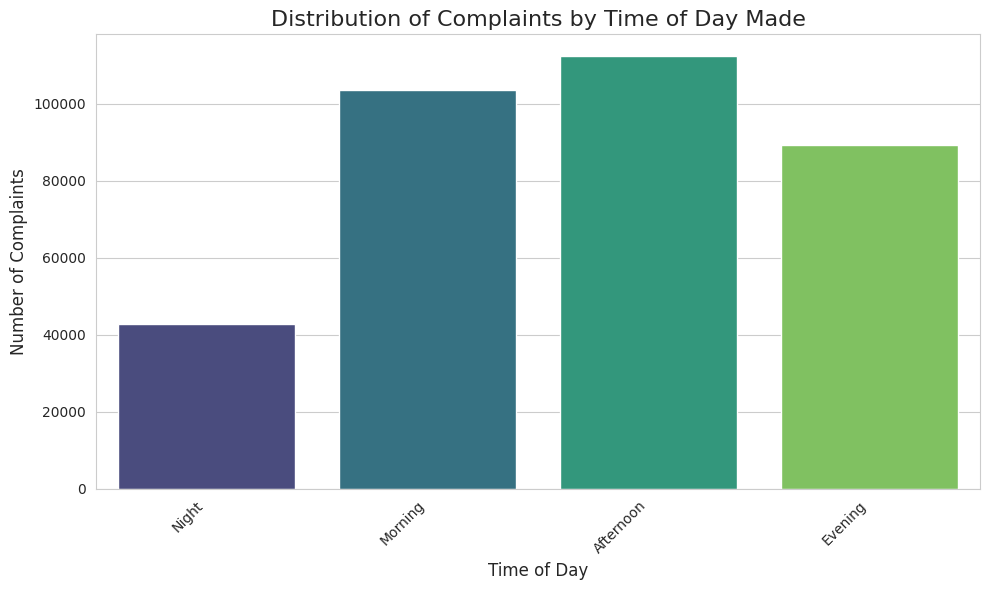

In [17]:
# Visualize Distribution of Complaints by Time of Day Made
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Created Time of Day', hue='Created Time of Day', legend=False, order=['Night', 'Morning', 'Afternoon', 'Evening'], palette='viridis')
plt.title('Distribution of Complaints by Time of Day Made', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


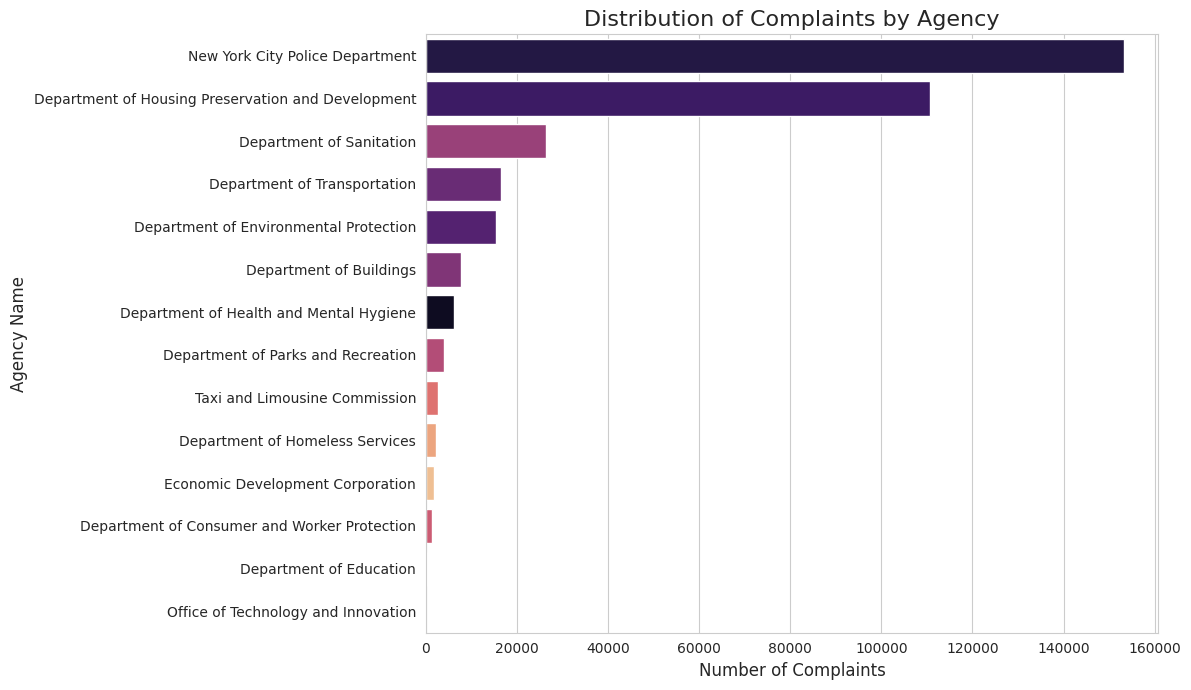

In [18]:
# Visualize Distribution of Complaints by Agency
plt.figure(figsize=(12, 7))
agency_counts = df['Agency Name'].value_counts().index
sns.countplot(data=df[df['Agency Name'].isin(agency_counts)], y='Agency Name', hue='Agency Name', legend=False, order=agency_counts, palette='magma')
plt.title('Distribution of Complaints by Agency', fontsize=16)
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Agency Name', fontsize=12)
plt.tight_layout()
plt.show()

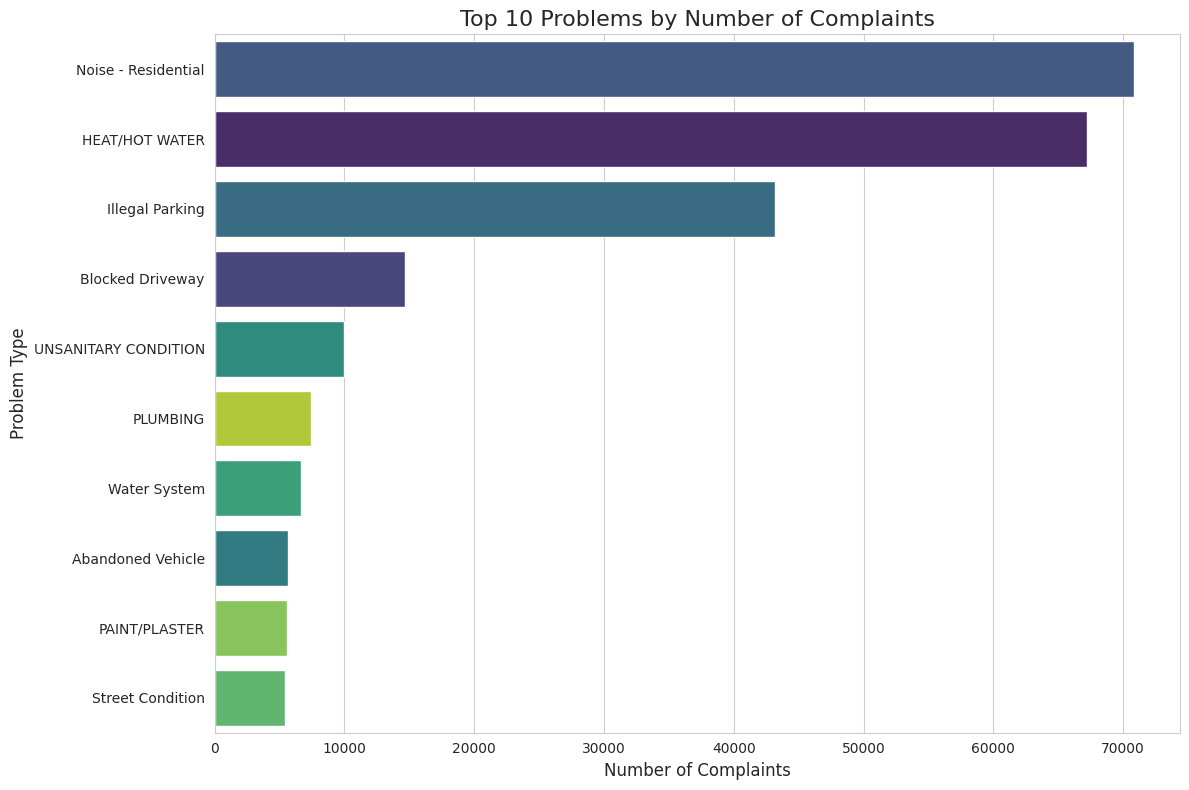

In [19]:
# Visualize Distribution of Complaint Count by Problem (Top 10 Problems)

plt.figure(figsize=(12, 8))
# Get the top 10 problems by complaint count
top_problems = df['Problem'].value_counts().head(10).index
sns.countplot(data=df[df['Problem'].isin(top_problems)], y='Problem', hue='Problem', legend=False, order=top_problems, palette='viridis')
plt.title('Top 10 Problems by Number of Complaints', fontsize=16)
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Problem Type', fontsize=12)
plt.tight_layout()
plt.show()

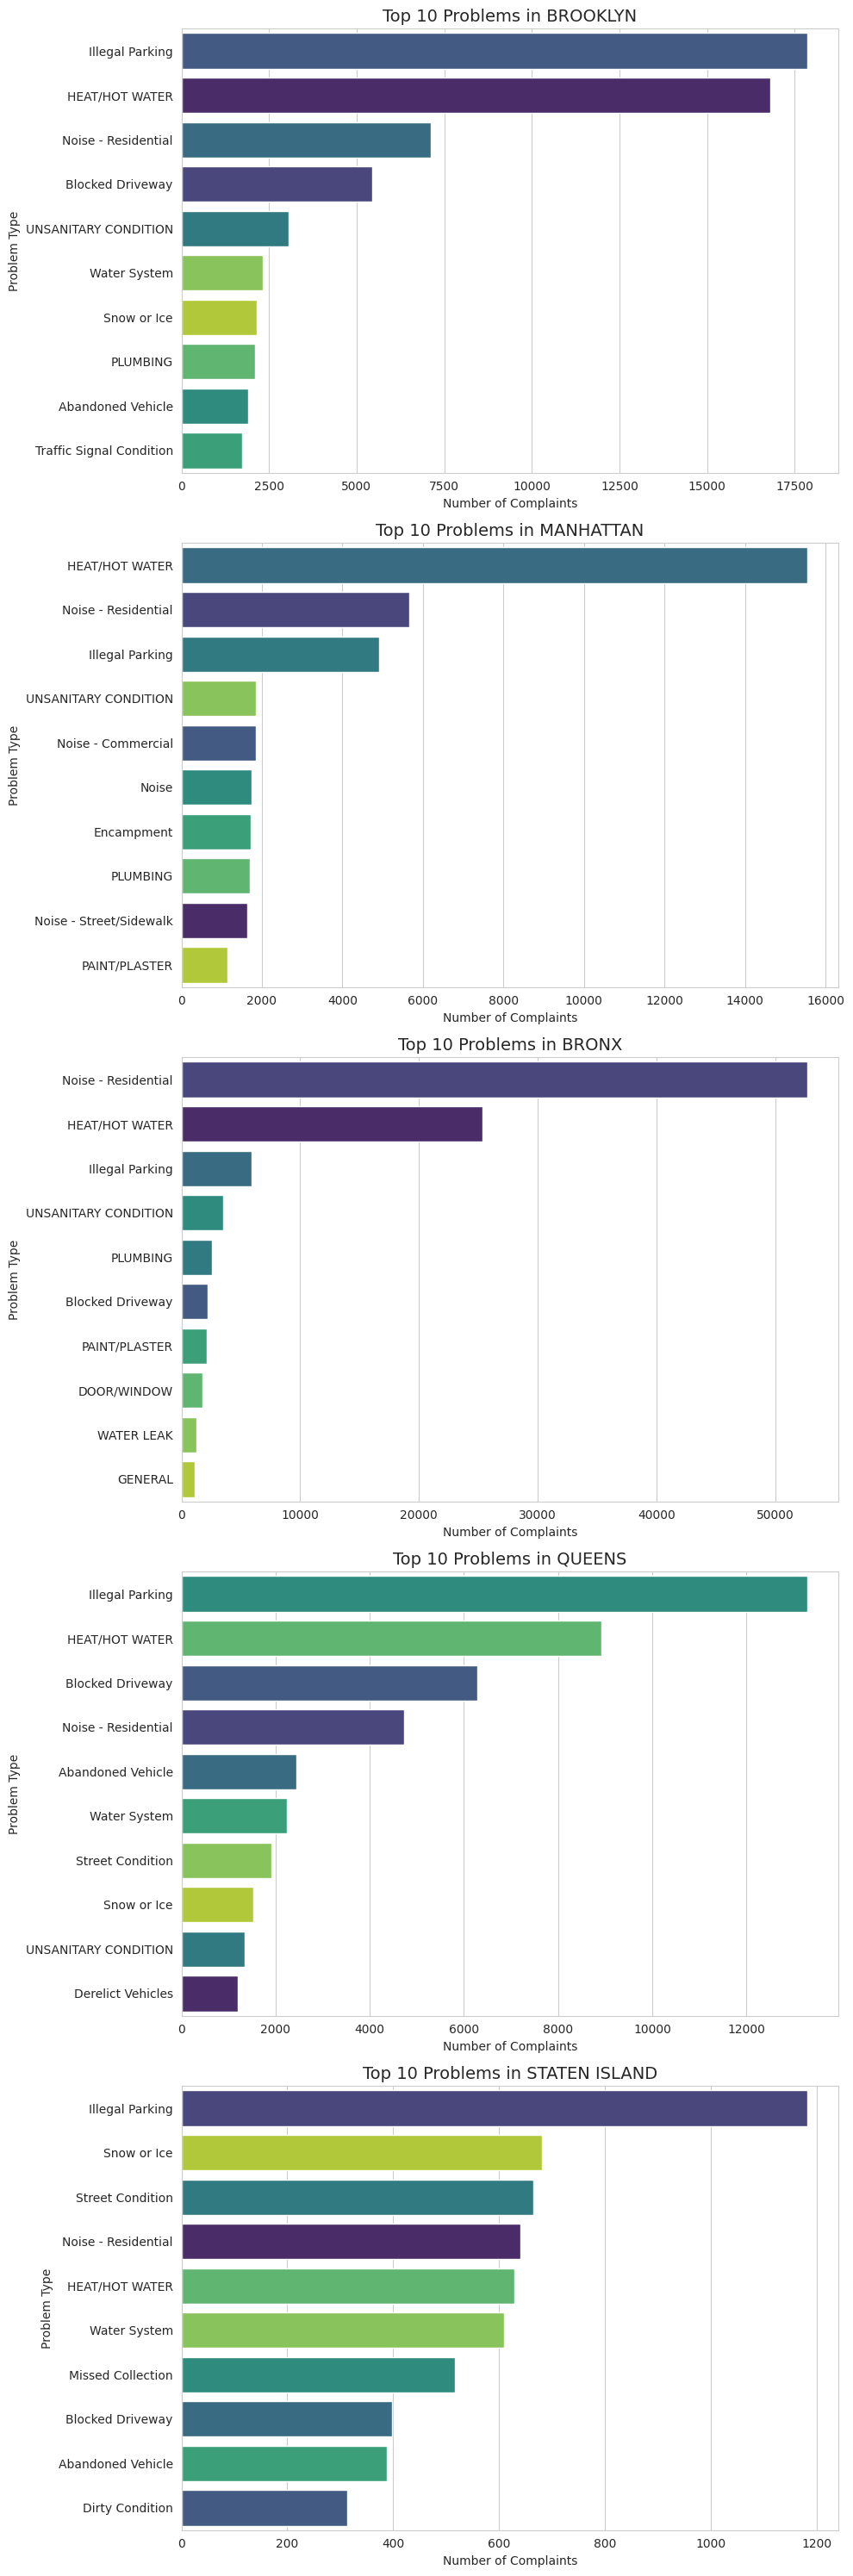

In [20]:
# Visualize top problems in each borough


unique_boroughs = df['Borough'].unique()

# Create a figure and a set of subplots. 5 rows, 1 column.
fig, axes = plt.subplots(len(unique_boroughs), 1, figsize=(10, 30), sharex=False)

for i, borough in enumerate(unique_boroughs):
    # Filter data for the current borough
    df_borough = df[df['Borough'] == borough]

    # Get the top 10 problems for this borough
    top_problems_borough = df_borough['Problem'].value_counts().head(10).index

    # Create a countplot on the corresponding subplot axis
    sns.countplot(data=df_borough[df_borough['Problem'].isin(top_problems_borough)],
                  y='Problem', hue='Problem', legend=False, order=top_problems_borough, palette='viridis', ax=axes[i])

    axes[i].set_title(f'Top 10 Problems in {borough}', fontsize=14)
    axes[i].set_xlabel('Number of Complaints', fontsize=10)
    axes[i].set_ylabel('Problem Type', fontsize=10)

plt.tight_layout()
plt.show()

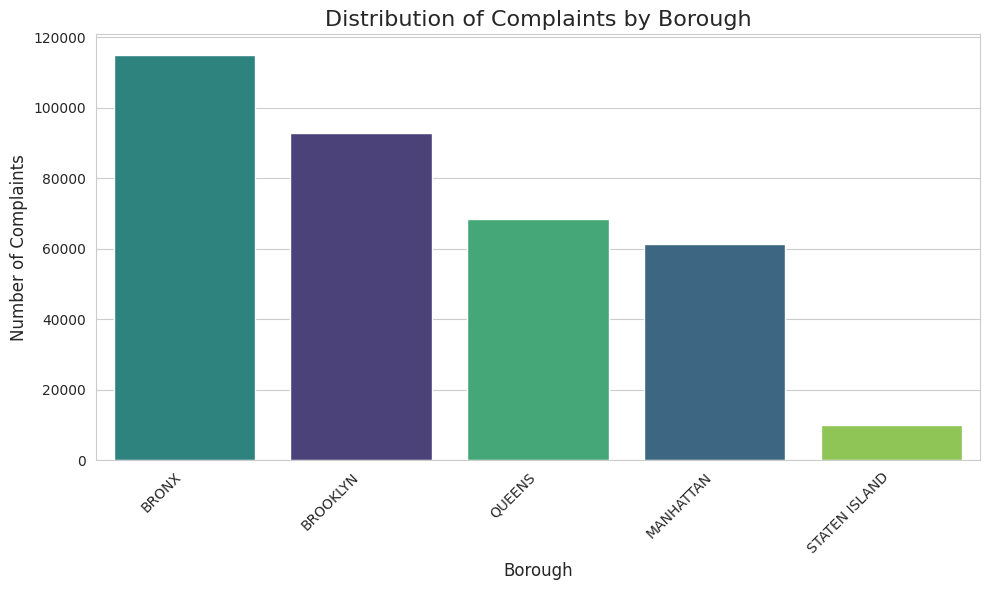

In [21]:
#Visualize Distribution of Complaints by Borough

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Borough', hue='Borough', legend=False, palette='viridis', order=df['Borough'].value_counts().index)
plt.title('Distribution of Complaints by Borough', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Distribution of Complaints by Resolution Days

In [22]:
# Printing summary statistics on Resoultion Days
print('Resolution Days: Summary Statistics')
print(df['Resolution Days'].describe())

Resolution Days: Summary Statistics
count    345208.000000
mean          9.663205
std          33.695469
min           0.000000
25%           0.079653
50%           0.626765
75%           2.847607
max         511.887616
Name: Resolution Days, dtype: float64


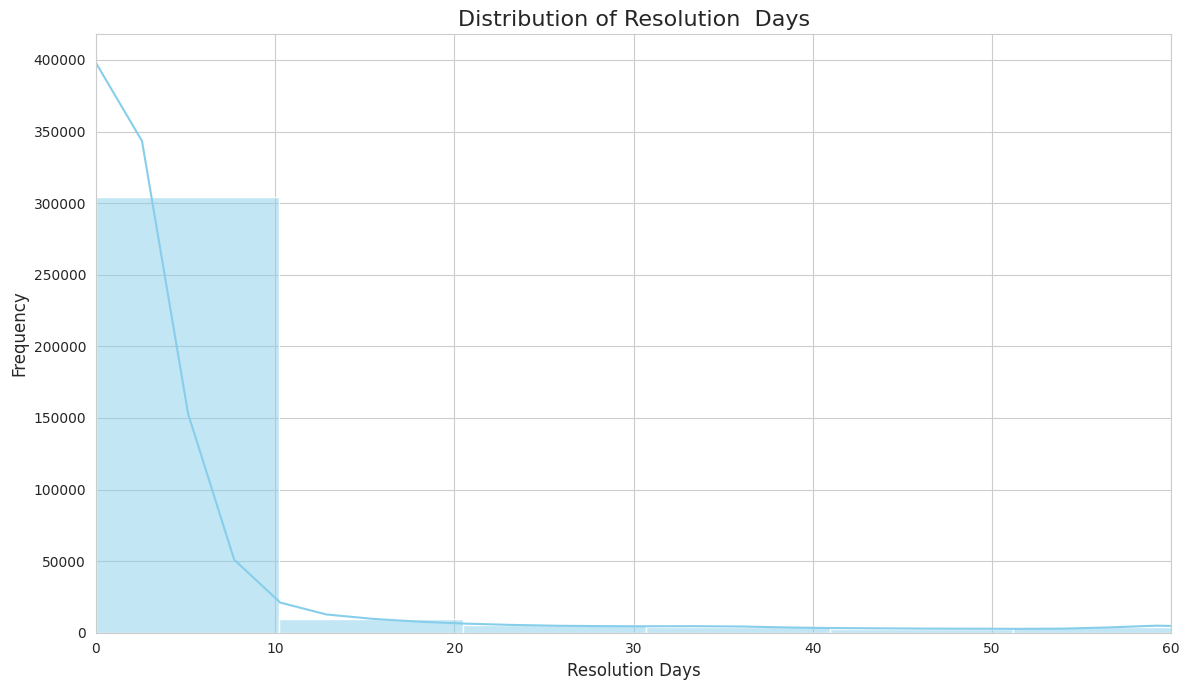

In [23]:
# Displaying a histogram on Resolution Days Distribution
plt.figure(figsize=(12, 7))
sns.histplot(df['Resolution Days'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Resolution  Days', fontsize=16)
plt.xlabel('Resolution Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Adjust x-axis limit to the 95th percentile to better visualize the bulk of the data
plt.xlim(0, df['Resolution Days'].quantile(0.95))
plt.tight_layout()
plt.show()

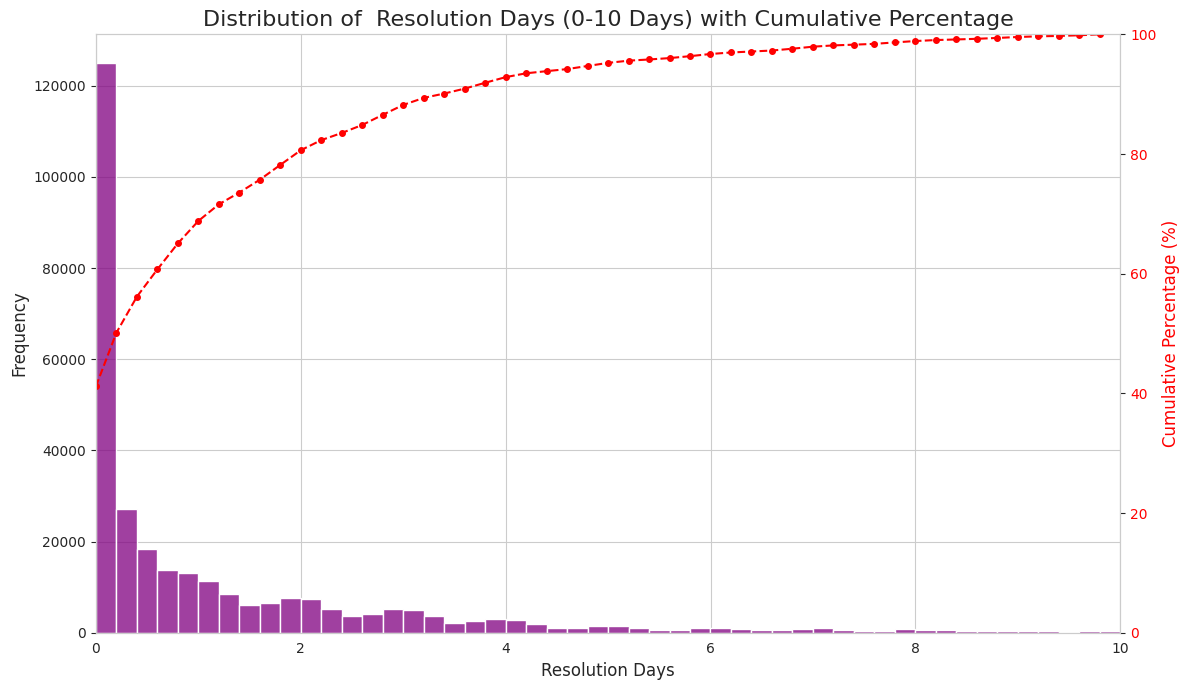

In [24]:
# Making a histogram with a more granular view of most values

# Filter data for resolution times between 0 and 10 days
df_filtered_0_10 = df[(df['Resolution Days'] >= 0) & (df['Resolution Days'] <= 10)]['Resolution Days'].dropna()

plt.figure(figsize=(12, 7))
ax = sns.histplot(df_filtered_0_10, bins=50, kde=False, color='purple') # Turn off KDE for this plot
plt.title('Distribution of  Resolution Days (0-10 Days) with Cumulative Percentage', fontsize=16)
plt.xlabel('Resolution Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 10) # Explicitly set x-limit for clarity

# Calculate cumulative percentage
n, bins, patches = ax.hist(df_filtered_0_10, bins=50, cumulative=True, density=True, histtype='step', alpha=0)
cum_percentage = n * 100

# Create a secondary y-axis for cumulative percentage
ax2 = ax.twinx()
ax2.plot(bins[:-1], cum_percentage, color='red', linestyle='--', marker='o', markersize=4, label='Cumulative Percentage')
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) # Turn off grid for the secondary axis
ax2.set_ylim(0, 100) # Ensure y-axis for percentage goes from 0 to 100

plt.tight_layout()
plt.show()

Insights:
The Resolution Days values are highly right skewed. The vast majority of tickets are resolved within 3 days, while a small proportion of tickets take a long time to resolve. We can examine what factors influence resolution time.

## Median Resolution Time by Various Parameters: Tables and Charts
### Median Resolution Time by Agency Name

In [25]:
median_resolution_agency = df.groupby('Agency Name')['Resolution Days'].median().sort_values(ascending=False)
display(median_resolution_agency)

,Resolution Days
Agency Name,
Economic Development Corporation,142.122500
Taxi and Limousine Commission,69.083883
Department of Education,34.960822
Office of Technology and Innovation,8.434433
Department of Parks and Recreation,5.889410
Department of Buildings,5.734740
Department of Consumer and Worker Protection,3.477784
Department of Housing Preservation and Development,2.748252
Department of Health and Mental Hygiene,1.709988


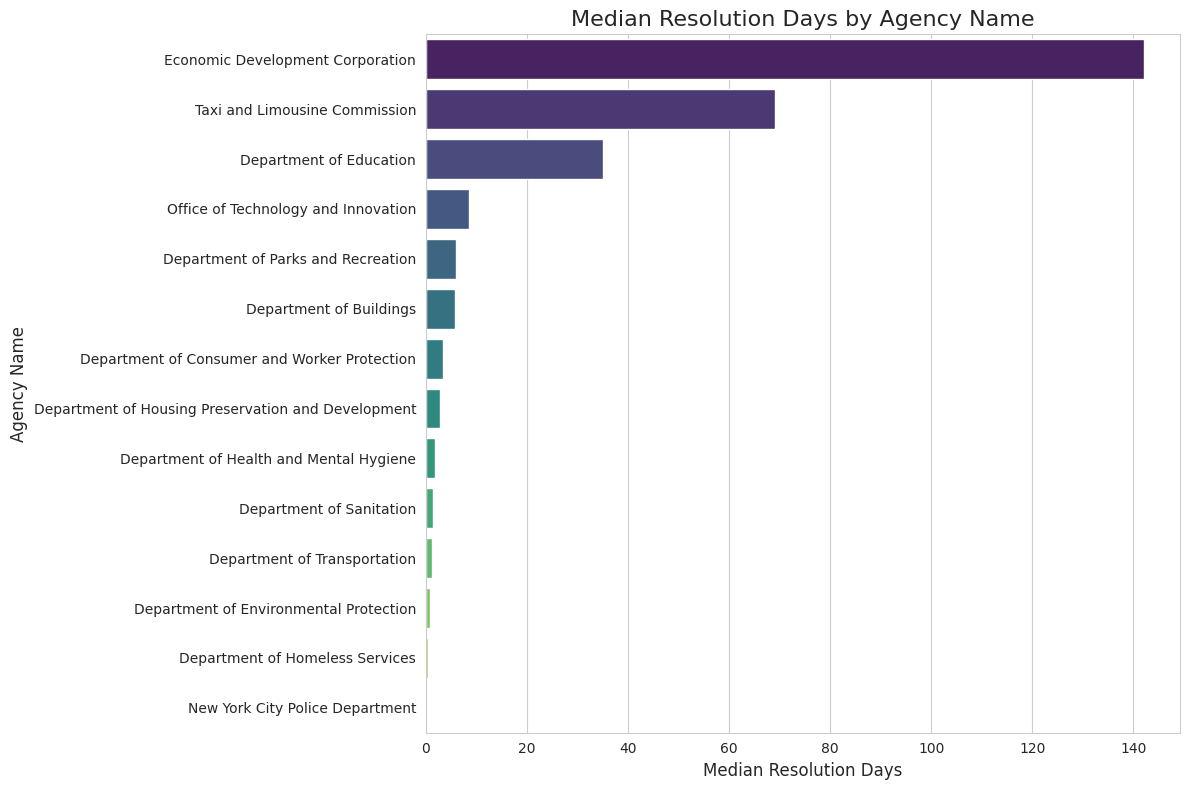

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(x=median_resolution_agency.values, y=median_resolution_agency.index, hue=median_resolution_agency.index, palette='viridis', legend=False)
plt.title('Median Resolution Days by Agency Name', fontsize=16)
plt.xlabel('Median Resolution Days', fontsize=12)
plt.ylabel('Agency Name', fontsize=12)
plt.tight_layout()
plt.show()

### Insight on Agency Disparities:
There is a wide degree of difference in median resolution days among various agencies. Looking at the agencies with varying median resolution days, it appears that agency name may correlate with complaint urgency. The agencies that resolve tickets most quickly are: NYC Police Department, Department of Homeless Services, and Department of Environmental Protection. These seem likely to have the most urgent complaints, such as crime in progress, homeless people in urgent need, or dangerous environmental conditions. Going up the list by increasing median Days Resolved seems to accord with expected complaints of lesser urgency. For example, the agency with the longest median resoution time is Economic Development Corporation. We can imagine that economic development is a long process and related complaints can take a long time to address.

### Median Resolution Time by Problem
There are 163 different Problems, so it is hard to look at all of them. Let's look at the top 20 and bottom 20 by median resolution days (among Problems where the median is non-null):

In [27]:
median_resolution_problem = df.groupby('Problem')['Resolution Days'].median().sort_values(ascending=False).dropna()
display(median_resolution_problem.head(20))
display(median_resolution_problem.sort_values(ascending=True).head(20))

,Resolution Days
Problem,
Special Natural Area District (SNAD),369.385903
Borough Office,304.152650
Uprooted Stump,208.679149
New Tree Request,147.771100
Noise - Helicopter,142.122500
For Hire Vehicle Complaint,77.579051
Taxi Complaint,75.015804
Green Taxi Complaint,69.295781
Building/Use,60.169132


,Resolution Days
Problem,
Animal Facility - No Permit,0.000000
Pet Shop,0.000000
Illegal Animal Kept as Pet,0.000000
Illegal Animal Sold,0.000000
Rodent,0.000000
Unleashed Dog,0.000000
Unsanitary Animal Pvt Property,0.000000
Unsanitary Animal Facility,0.000000
Vendor Enforcement,0.016887


###Insights from Problem Distribution
The main insight here is that Problem as a category is too disperse to analyze--we have problems with median Distribution Days of zero (no actual resolution process) and some with very high median Distribution Days (clearly represent very few cases). But on the whole we can see that the urgency explanation seems to hold: the most quickly resolved problems appear relatively urgent (noise, drug activity, disorders, homeless person assistance), whereas the slower resolved problems appear generally to be less urgent. Though again, this allocation isn't worth too much attention because it's showing many small groups that consist of outliers.

### Median Resolution Time by Community Board

In [28]:
median_resolution_community_board = df.groupby('Community Board')['Resolution Days'].median().sort_values(ascending=False)
display(median_resolution_community_board)

,Resolution Days
Community Board,
84 QUEENS,75.540307
83 QUEENS,65.899618
80 QUEENS,63.664595
28 BRONX,11.418519
55 BROOKLYN,6.880602
...,...
06 BROOKLYN,0.070747
02 BROOKLYN,0.069167
56 BROOKLYN,0.068519


###Insights from Community Board Distribution
There is a broad variety of median Distribution Days among Community Board groups. Yet given there are 76 different groups and without knowledge about particular characteristics of each community board group and its size, and analyzing the distribution of complaints from each group here, this information isn't worth too much attention. The number of groups also makes this variable less useful for Machine Learning later.

### Median Resolution Time by Borough

In [29]:
median_resolution_borough = df.groupby('Borough')['Resolution Days'].median().sort_values(ascending=False)
display(median_resolution_borough)

,Resolution Days
Borough,
MANHATTAN,1.326696
STATEN ISLAND,0.836400
BROOKLYN,0.736829
BRONX,0.545978
QUEENS,0.349687


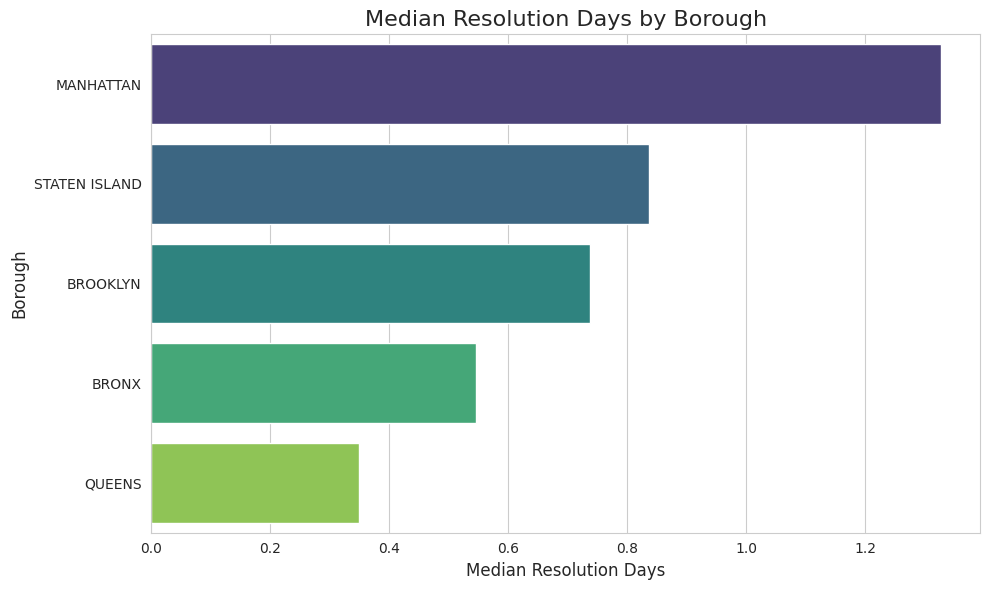

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x=median_resolution_borough.values, y=median_resolution_borough.index, hue=median_resolution_borough.index, palette='viridis', legend=False)
plt.title('Median Resolution Days by Borough', fontsize=16)
plt.xlabel('Median Resolution Days', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.tight_layout()
plt.show()

### Insight: Median Resolution Days by Borough

There is a disparity in resolution days by borough, though it is much smaller than the disparity by agency and the by category. It is somewhat surprising that Manhattan, the most central and dense borough, has a longer median resolution time. However, this disparity may not be very significant and may be a proxy for other factors that correlate with borough. I will wait for the discussion of modeling findings to discuss this further.

In [31]:
# Output the cleaned df for use in Tableau:
df.to_csv('cleaned_311_data.csv', index=False)

### Further Feature Engineering: Creating the Category Variable
After noticing that the Problem variable had way too many unique values to be useful in Machine Learning (with each unique value minus one becoming a dummy variable), I decided to create a new variable, Category. I created a .csv file with all the unique values of Problem, and then created 15 categories for similar problems. This reduced 163 messy labels to 15 meaningful ones. Based on the .csv file of unique Problems, I created a file mapping each Problem to the category I assigned it, problems_categories.xlsx. I then joined this mapping file to the dataframe I was working with to add the Category to each row.

Here is a link to problems_categories.xlsx: https://1drv.ms/x/c/5d4848e22c1ff224/IQA1j2Uc9JzjRaYn7BE5SMBWAfQLWCdrTkquE66DJSxLNBg?e=c8nEBl


In [32]:
# Creating a .csv file of unique problems

unique_problems = df['Problem'].unique()
print('All unique values of Problem:')
display(unique_problems)

All unique values of Problem:


array(['Food Poisoning', 'Noise - Street/Sidewalk', 'HEAT/HOT WATER',
       'Blocked Driveway', 'Noise', 'Traffic Signal Condition',
       'Noise - Vehicle', 'Noise - Residential', 'Illegal Parking',
       'Smoking or Vaping', 'Noise - Commercial',
       'General Construction/Plumbing', 'Derelict Vehicles',
       'Abandoned Vehicle', 'Dirty Condition', 'Encampment',
       'UNSANITARY CONDITION', 'Litter Basket Request', 'Drinking',
       'Sewer', 'Obstruction', 'Illegal Posting', 'Animal-Abuse',
       'Maintenance or Facility', 'Illegal Dumping', 'Damaged Tree',
       'Street Sign - Damaged', 'Water System',
       'Non-Emergency Police Matter', 'Food Establishment',
       'Street Condition', 'Building/Use', 'Consumer Complaint',
       'Air Quality', 'Boilers', 'Residential Disposal Complaint',
       'Noise - House of Worship', 'PAINT/PLASTER',
       'Street Light Condition', 'PLUMBING', 'APPLIANCE', 'WATER LEAK',
       'SAFETY', 'Indoor Air Quality', 'Graffiti', 'Elevato

In [33]:
# Convert the numpy array to a pandas Series for easier export
unique_problems_series = pd.Series(unique_problems)

# Export the Series to a CSV file
unique_problems_series.to_csv('unique_problems.csv', index=False, header=False)

print("Unique problems exported to unique_problems.csv")

Unique problems exported to unique_problems.csv


In [34]:
# Importing the problems_categories mapping file and joining it to df to add Category column.

# Import problems_categories.xlsx
problems_categories = pd.read_excel('problems_categories.xlsx')

# Display the first few rows and info of the new dataframe to verify
print("Problems Categories DataFrame Head:")
print(problems_categories.head())
print("\nProblems Categories DataFrame Info:")
problems_categories.info()

# Add the Category column to df using a merge operation
# We'll perform a left merge on 'df' to keep all its rows, matching on 'Problem'
df = pd.merge(df, problems_categories[['Problem', 'Category']], on='Problem', how='left')

# Verify the new 'Category' column in df
print("\nDataFrame 'df' with new 'Category' column (head):")
print(df.head())
print("\nDataFrame 'df' info after adding 'Category' column:")
df.info()

Problems Categories DataFrame Head:
                   Problem              Category
0           Food Poisoning      Business Conduct
1  Noise - Street/Sidewalk                 Noise
2           HEAT/HOT WATER  Building Maintenance
3         Blocked Driveway           Car Conduct
4                    Noise                 Noise

Problems Categories DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Problem   152 non-null    object
 1   Category  152 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB

DataFrame 'df' with new 'Category' column (head):
   Unique Key        Created Date         Closed Date  \
0    63958778 2025-02-01 00:00:00 2025-02-03 08:43:25   
1    63950044 2025-01-31 23:59:48 2025-02-01 04:44:27   
2    63945541 2025-01-31 23:59:45 2025-02-01 17:35:57   
3    63947478 2025-01-31 23:59:19 2025-02-01 10:33:54   
4

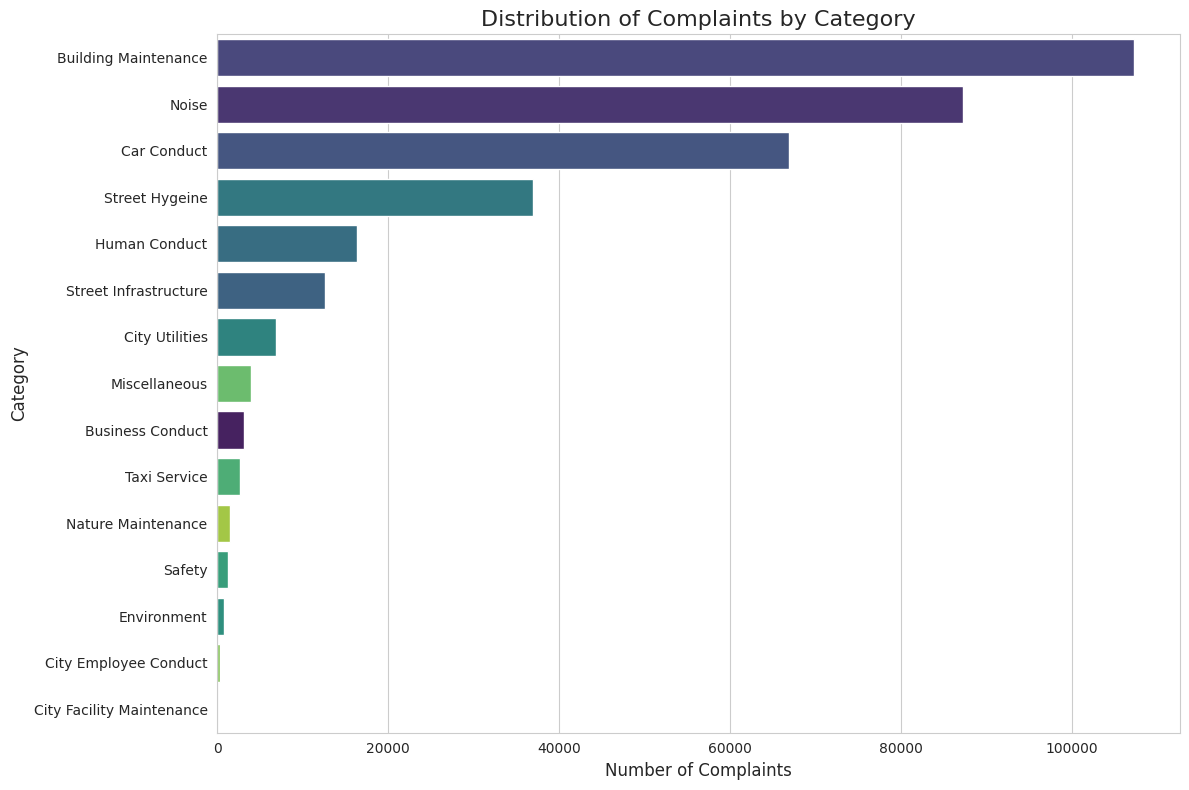

In [35]:
# Viz: Distribution of Complaints by Category
plt.figure(figsize=(12, 8))
category_counts = df['Category'].value_counts().index
sns.countplot(data=df[df['Category'].isin(category_counts)], y='Category', hue='Category', legend=False, order=category_counts, palette='viridis')
plt.title('Distribution of Complaints by Category', fontsize=16)
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
# Table: Median Resolution Days by Category
median_resolution_category = df.groupby('Category')['Resolution Days'].median().sort_values(ascending=False)
print('Median Resolution Days by Category')
display(median_resolution_category)

Median Resolution Days by Category


,Resolution Days
Category,
Taxi Service,69.083883
Miscellaneous,11.194028
Safety,10.197500
City Facility Maintenance,7.955440
City Employee Conduct,3.935816
Nature Maintenance,2.866736
Business Conduct,2.802963
Building Maintenance,2.405312
Street Hygeine,2.202928


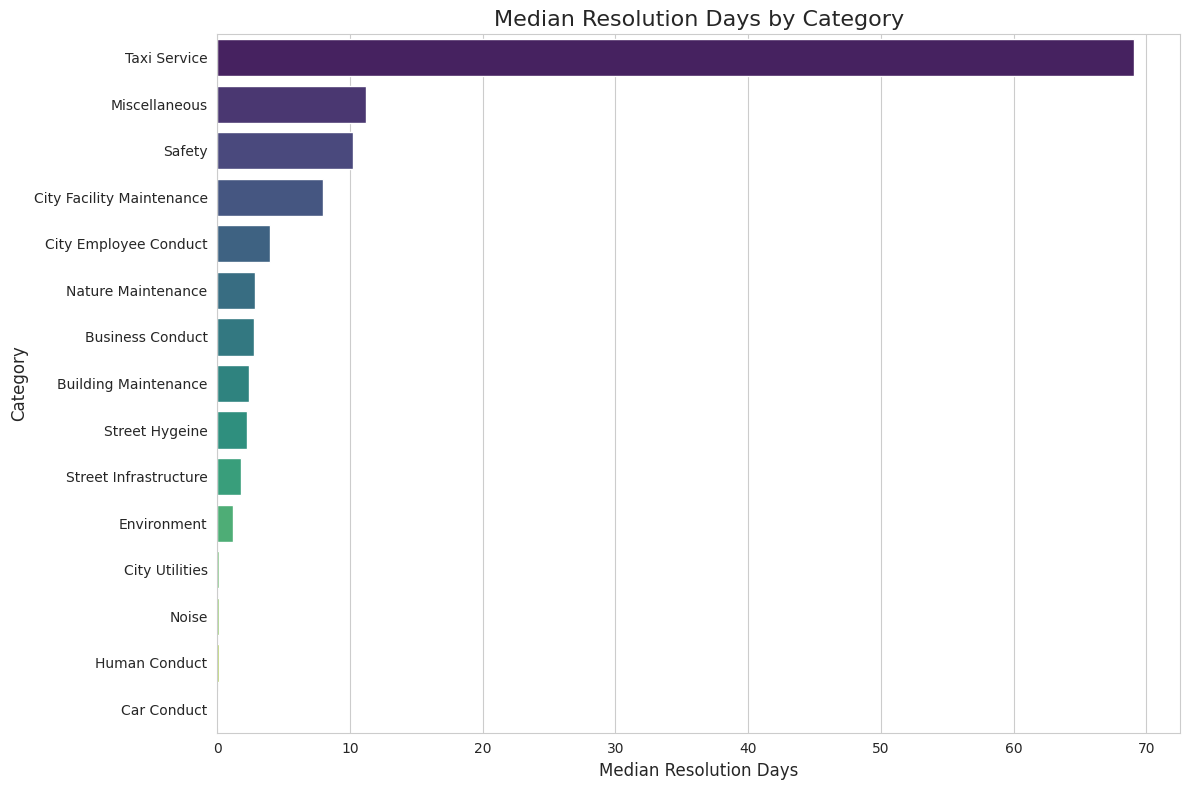

In [37]:
# Viz: Median Resolution Days by Category
plt.figure(figsize=(12, 8))
sns.barplot(x=median_resolution_category.values, y=median_resolution_category.index, hue=median_resolution_category.index, palette='viridis', legend=False)
plt.title('Median Resolution Days by Category', fontsize=16)
plt.xlabel('Median Resolution Days', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

### Insight: Median Resolution Days by Category
This data mostly supports the idea that urgency is a major factor affecting resolution time. The quickest resolved categories--Car Conduct, Human Conduct, Noise, and City Utilities (including water quality)--refer to urgent issues that understandably were resolved quickly. The slowest resolved categories were Taxi Service, Miscellaneous, Safety, and City Facility Maintenance. City Facility Maintenance appears to be a less urgent category. What about Safety, Miscellaneous, and Taxi Service? All are pretty uncommon (as seen in the distribution chart), so they don't warrant much attention, though the very high median of Taxi Service remains unexpected and may be worth further consideration after modeling.

### Machine Learning Modeling
After all this prep and analysis, I went forward with Machine Learning modeling to examine how Category, Agency, Borough, and Created Time of Day affected Resolution Days.
I first tried creating a model to predict Resolution Days. One concern with such modeling is that Resolution Days is heavily right-skewed (a small number of tickets drag on for a long time), as can be seen in the distribution histograms above. I used Log(Resolution Days) as the target variable to alleviate this issue.

In [38]:
#Setting up data for ML
# 1. Create Log(Resolution Days) as the target variable (Y)
# Add a small constant to Resolution Days to avoid log(0) issues
df['Log_Resolution_Days'] = np.log(df['Resolution Days'] + 1e-6)

# 2. Handle missing values in relevant columns before modeling
# Drop rows where 'Resolution Days' (and thus 'Log_Resolution_Days') is NaN
# or where any of the X values is NaN, as these are critical for the model
df_model = df.dropna(subset=['Log_Resolution_Days', 'Category', 'Agency Name', 'Borough', 'Created Time of Day']).copy()

# Display the head and info of the new df_model
print("DataFrame for modeling (head):")
print(df_model[['Log_Resolution_Days', 'Category', 'Agency Name', 'Borough', 'Created Time of Day']].head())
print("\nDataFrame for modeling (info after dropping NaNs):")
df_model.info()

DataFrame for modeling (head):
   Log_Resolution_Days              Category  \
0             0.860137      Business Conduct   
1            -1.621133                 Noise   
2            -0.309964  Building Maintenance   
3            -0.819428           Car Conduct   
4             1.084861                 Noise   

                                         Agency Name    Borough  \
0            Department of Health and Mental Hygiene   BROOKLYN   
1                    New York City Police Department  MANHATTAN   
2  Department of Housing Preservation and Develop...   BROOKLYN   
3                    New York City Police Department   BROOKLYN   
4             Department of Environmental Protection      BRONX   

  Created Time of Day  
0               Night  
1             Evening  
2             Evening  
3             Evening  
4             Evening  

DataFrame for modeling (info after dropping NaNs):
<class 'pandas.core.frame.DataFrame'>
Index: 345182 entries, 0 to 347906
Data col

In [39]:
# 3. Create dummy variables for categorical features
X = pd.get_dummies(df_model[['Category', 'Agency Name', 'Borough', 'Created Time of Day']], drop_first=True)
y = df_model['Log_Resolution_Days']

print("Shape of X (features):")
print(X.shape)
print("Shape of y (target):")
print(y.shape)
print("\nFirst 5 rows of X (features):")
print(X.head())
print("\nFirst 5 rows of y (target):")
print(y.head())

Shape of X (features):
(345182, 34)
Shape of y (target):
(345182,)

First 5 rows of X (features):
   Category_Business Conduct  Category_Car Conduct  \
0                       True                 False   
1                      False                 False   
2                      False                 False   
3                      False                  True   
4                      False                 False   

   Category_City Employee Conduct  Category_City Facility Maintenance  \
0                           False                               False   
1                           False                               False   
2                           False                               False   
3                           False                               False   
4                           False                               False   

   Category_City Utilities  Category_Environment  Category_Human Conduct  \
0                    False                 False              

In [40]:
# 4. Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (276145, 34)
X_test shape: (69037, 34)
y_train shape: (276145,)
y_test shape: (69037,)


### First ML model used: Random Forest Regressor

Random Forest Regressor is a robust choice for this task because it effectively handles various data types (including the dummy variables we created for categorical features), is less prone to overfitting than single decision trees, and can capture complex, non-linear relationships in the data. It also provides insights into feature importance.

In [41]:
# 5. Train a Machine Learning Model (RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
# Using a small number of estimators for quicker demonstration, adjust as needed
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training RandomForestRegressor...")
model.fit(X_train, y_train)
print("Training complete.")

# 6. Make predictions on the test set
y_pred = model.predict(X_test)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Training RandomForestRegressor...
Training complete.

Model Evaluation:
Mean Squared Error (MSE): 3.9899
R-squared (R2): 0.5077


The R-squared value of 0.5077 indicates that approximately 50.77% of the variance in Log(Resolution Days) can be explained by the features included in the model. This is not a great result for a model.

I next tried Linear Regression:

In [42]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
print("Training Linear Regression model...")
linear_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"\nLinear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"R-squared (R2): {r2_linear:.4f}")

Training Linear Regression model...
Training complete.

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 4.6730
R-squared (R2): 0.4234


As we can see, the Random Forest Regressor performed better with a lower MSE and a higher R-squared value, indicating it explains more of the variance in Log(Resolution Days). This is not surprising, as Random Forests are generally more capable of capturing complex, non-linear relationships in data compared to simpler linear models.

It seems that using ML to predict the log of Resolution Days is of limited effectiveness, likely because the data is heavily right-skewed.

So I tried a different modeling approach, classfication: predicting whether a ticket will be resolved within a given amount of time. This can be a more useful and effective modeling approach for heavily right-skewed data, as it is likely to be cleaner and more robust to the skew. The median Resolution Days is 0.626765, so most tickets are resolved within a day, which may be a reasonable amount of time to expect a problem to be resolved (depending on the problem). So one day is a meaningful threshold for a classification model.
First I checked the class balance for the threshold of one day.

In [43]:
resolved_within_1_day = df['Resolution Days'] <= 1

class_balance = resolved_within_1_day.value_counts(normalize=True) * 100

print("Class balance for Resolution Days <= 1 day:")
print(class_balance)


Class balance for Resolution Days <= 1 day:
Resolution Days
True     56.804548
False    43.195452
Name: proportion, dtype: float64


This indicates a reasonably balanced dataset, which is good for training a classification model, as it means neither class is overwhelmingly dominant. So I went on to use 1 as my Resolution Days threshold and to conduct classification modeling, first using a Random Forest Classifier model.

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 1. Prepare data for classification
# Features X are the same as used for regression, but we'll rename to X_class for clarity
X_class = X.copy() # X was already defined from df_model[['Category', 'Agency Name', 'Borough', 'Created Time of Day']] and one-hot encoded

# Target variable for classification: resolved within 1 day (True/False)
# Convert boolean to integer (0 or 1) for classification model
y_class = (df_model['Resolution Days'] <= 1).astype(int)

print(f"Shape of X_class (features): {X_class.shape}")
print(f"Shape of y_class (target): {y_class.shape}")

# 2. Split data into training and testing sets for classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class) # Stratify to maintain class balance

print(f"\nX_train_class shape: {X_train_class.shape}")
print(f"X_test_class shape: {X_test_class.shape}")
print(f"y_train_class shape: {y_train_class.shape}")
print(f"y_test_class shape: {y_test_class.shape}")

# 3. Initialize and Train the RandomForestClassifier model
class_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced') # Use class_weight for potentially imbalanced classes

print("\nTraining RandomForestClassifier model...")
class_model.fit(X_train_class, y_train_class)
print("Training complete.")

# 4. Make predictions on the test set
y_pred_class = class_model.predict(X_test_class)
y_pred_proba_class = class_model.predict_proba(X_test_class)[:, 1] # Probability of the positive class (resolved <= 1 day)

# 5. Evaluate the model
accuracy_class = accuracy_score(y_test_class, y_pred_class)
precision_class = precision_score(y_test_class, y_pred_class)
recall_class = recall_score(y_test_class, y_pred_class)
f1_class = f1_score(y_test_class, y_pred_class)
roc_auc_class = roc_auc_score(y_test_class, y_pred_proba_class)

print(f"\nRandomForestClassifier Model Evaluation:")
print(f"Accuracy: {accuracy_class:.4f}")
print(f"Precision: {precision_class:.4f}")
print(f"Recall: {recall_class:.4f}")
print(f"F1-Score: {f1_class:.4f}")
print(f"ROC AUC Score: {roc_auc_class:.4f}")

# Confusion Matrix
print("\nConfusion Matrix (RandomForestClassifier):")
print(confusion_matrix(y_test_class, y_pred_class))

# Classification Report
print("\nClassification Report (RandomForestClassifier):")
print(classification_report(y_test_class, y_pred_class, target_names=['> 1 Day', '<= 1 Day']))

Shape of X_class (features): (345182, 34)
Shape of y_class (target): (345182,)

X_train_class shape: (276145, 34)
X_test_class shape: (69037, 34)
y_train_class shape: (276145,)
y_test_class shape: (69037,)

Training RandomForestClassifier model...
Training complete.

RandomForestClassifier Model Evaluation:
Accuracy: 0.8658
Precision: 0.9382
Recall: 0.8197
F1-Score: 0.8749
ROC AUC Score: 0.9306

Confusion Matrix (RandomForestClassifier):
[[27379  2134]
 [ 7128 32396]]

Classification Report (RandomForestClassifier):
              precision    recall  f1-score   support

     > 1 Day       0.79      0.93      0.86     29513
    <= 1 Day       0.94      0.82      0.87     39524

    accuracy                           0.87     69037
   macro avg       0.87      0.87      0.87     69037
weighted avg       0.88      0.87      0.87     69037



### Classification Model Evaluation Summary

**RandomForestClassifier Performance:**

The RandomForestClassifier model, trained to predict whether a ticket will be resolved within one day (`<= 1 Day`) or take longer (`> 1 Day`), demonstrates strong performance, with an overall accuracy of **86.58%**.

**Key Metrics:**

*   **Accuracy:** 0.8658
*   **Precision:** 0.9382 (for `<= 1 Day` class)
*   **Recall:** 0.8197 (for `<= 1 Day` class)
*   **F1-Score:** 0.8749 (for `<= 1 Day` class)
*   **ROC AUC Score:** 0.9306

**Classification Report Breakdown:**

| Class       | Precision | Recall | F1-Score | Support |
| :---------- | :-------- | :----- | :------- | :------ |
| `> 1 Day`   | 0.79      | 0.93   | 0.86     | 29513   |
| `<= 1 Day`  | 0.94      | 0.82   | 0.87     | 39524   |

**Interpretation:**

*   The model is highly effective at identifying tickets that will be resolved within one day, showing a high precision of 0.94 for this class. This means when the model predicts a quick resolution, it's correct 94% of the time.
*   For tickets that take longer than one day (`> 1 Day`), the model has a high recall of 0.93, indicating it successfully captures most of these cases.
*   The F1-Scores for both classes are well-balanced (0.86 and 0.87), suggesting a good trade-off between precision and recall.
*   The ROC AUC score of 0.9306 further confirms the model's excellent ability to distinguish between the two classes.

In [45]:
# Showing Feature Importances from this model:

# Get feature importances from the trained RandomForestClassifier
feature_importances = class_model.feature_importances_

# Get the feature names from X_class (which is X in this case)
feature_names = X_class.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from RandomForestClassifier:")
display(importance_df)

Feature Importances from RandomForestClassifier:


,Feature,Importance
24,Agency Name_New York City Police Department,0.458525
19,Agency Name_Department of Housing Preservation...,0.171547
9,Category_Noise,0.108347
1,Category_Car Conduct,0.107967
11,Category_Street Hygeine,0.021571
16,Agency Name_Department of Environmental Protec...,0.017661
21,Agency Name_Department of Sanitation,0.015010
28,Borough_MANHATTAN,0.009259
17,Agency Name_Department of Health and Mental Hy...,0.008504
4,Category_City Utilities,0.008484


## Classification Model: Logistic Regression

I next trained a Logistic Regression model for comparison and to get insights into the direction of feature impacts.

In [46]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter for convergence if needed, and solver for appropriate algorithm
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

print("Training Logistic Regression model...")
logistic_model.fit(X_train_class, y_train_class)
print("Training complete.")

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_class)
y_pred_proba_logistic = logistic_model.predict_proba(X_test_class)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy_logistic = accuracy_score(y_test_class, y_pred_logistic)
precision_logistic = precision_score(y_test_class, y_pred_logistic)
recall_logistic = recall_score(y_test_class, y_pred_logistic)
f1_logistic = f1_score(y_test_class, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test_class, y_pred_proba_logistic)

print(f"\nLogistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")
print(f"ROC AUC Score: {roc_auc_logistic:.4f}")

# Classification Report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_class, y_pred_logistic, target_names=['> 1 Day', '<= 1 Day']))

# Confusion Matrix
print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test_class, y_pred_logistic))


Training Logistic Regression model...
Training complete.

Logistic Regression Model Evaluation:
Accuracy: 0.8549
Precision: 0.9296
Recall: 0.8078
F1-Score: 0.8644
ROC AUC Score: 0.9185

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

     > 1 Day       0.78      0.92      0.84     29513
    <= 1 Day       0.93      0.81      0.86     39524

    accuracy                           0.85     69037
   macro avg       0.86      0.86      0.85     69037
weighted avg       0.87      0.85      0.86     69037


Confusion Matrix (Logistic Regression):
[[27096  2417]
 [ 7598 31926]]


### Logistic Regression Model Evaluation Summary

**Logistic Regression Performance:**

The Logistic Regression model, which serves as a more interpretable alternative to the Random Forest, also performs very well with an overall accuracy of **85.49%**.

**Key Metrics:**

*   **Accuracy:** 0.8549
*   **Precision:** 0.9296 (for `<= 1 Day` class)
*   **Recall:** 0.8078 (for `<= 1 Day` class)
*   **F1-Score:** 0.8644 (for `<= 1 Day` class)
*   **ROC AUC Score:** 0.9185

**Interpretation:**

*   **High Precision for Quick Resolutions:** Similar to the Random Forest, the Logistic Regression model has a high precision of 0.93 for the `<= 1 Day` class. This indicates that its predictions for quick resolutions are highly reliable.
*   **Strong Discriminative Ability:** An ROC AUC score of 0.9185 shows that the model has an excellent ability to distinguish between complaints that are resolved quickly versus those that take longer.
*   **Recall for Slower Resolutions:** The model shows a recall of 0.92 for the `> 1 Day` class, meaning it is very effective at capturing the vast majority of tickets that will exceed the one-day threshold.
*   **Overall Reliability:** While slightly lower in predictive power than the Random Forest (86.58% vs 85.49%), the Logistic Regression model remains a highly robust tool, with the added benefit of providing interpretable coefficients to understand feature impact.

### Interpreting Logistic Regression Coefficients

The coefficients from a Logistic Regression model indicate the strength and direction of the relationship between each feature and the log-odds of the positive class (in this case, `Resolution Days <= 1`).

-   A **positive coefficient** means that as the value of that feature increases, the log-odds of `Resolution Days <= 1` increases, implying a higher probability of quick resolution.
-   A **negative coefficient** means that as the value of that feature increases, the log-odds of `Resolution Days <= 1` decreases, implying a lower probability of quick resolution.

In [47]:
# Showing Feature Coefficients from Logistic Regression model

# Get feature names (assuming X_train_class has column names)
feature_names = X_train_class.columns

# Get the coefficients from the trained Logistic Regression model
coefficients = logistic_model.coef_[0] # For binary classification, there's one set of coefficients

# Create a DataFrame for better readability
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by the absolute value of the coefficient to see the most influential features
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("Logistic Regression Feature Coefficients (sorted by absolute value):")
display(coefficients_df)


Logistic Regression Feature Coefficients (sorted by absolute value):


,Feature,Coefficient
24,Agency Name_New York City Police Department,5.074047
23,Agency Name_Economic Development Corporation,-3.746790
2,Category_City Employee Conduct,-2.107510
18,Agency Name_Department of Homeless Services,1.871488
15,Agency Name_Department of Education,-1.620427
16,Agency Name_Department of Environmental Protec...,1.409962
9,Category_Noise,-1.368816
3,Category_City Facility Maintenance,-1.307119
10,Category_Safety,-1.211919
22,Agency Name_Department of Transportation,1.187306


In [48]:
# Small calculation for conclusions: Proportion of Noise complaints handled by NYPD

# Filter for Noise complaints
noise_complaints = df[df['Category'] == 'Noise']

# Filter for Noise complaints handled by NYPD
nypd_noise_complaints = noise_complaints[noise_complaints['Agency Name'] == 'New York City Police Department']

# Calculate the proportion
proportion = len(nypd_noise_complaints) / len(noise_complaints)

print(f"Proportion of Noise complaints handled by NYPD: {proportion:.2%}")

Proportion of Noise complaints handled by NYPD: 93.07%


In [49]:
# Creating and exporting a .csv with the full df_raw info and categories.
# 1. Rename the column in df_raw for consistent merging
df_raw_renamed = df_raw.rename(columns={'Problem (formerly Complaint Type)': 'Problem'})

# 2. Join the Category mapping to df_raw
df_raw_with_cat = pd.merge(df_raw_renamed, problems_categories[['Problem', 'Category']], on='Problem', how='left')

# 3. Save as a new .csv
df_raw_with_cat.to_csv('311_data_with_categories.csv', index=False)

print(f"Success! '311_data_with_categories.csv' created with {len(df_raw_with_cat)} rows.")
display(df_raw_with_cat[['Problem', 'Category']].head())

Success! '311_data_with_categories.csv' created with 348181 rows.


,Problem,Category
0,Food Poisoning,Business Conduct
1,Noise - Street/Sidewalk,Noise
2,HEAT/HOT WATER,Building Maintenance
3,Blocked Driveway,Car Conduct
4,Noise,Noise


In [50]:
# --- Analysis for 'Taxi Service' Category ---

# Filter DataFrame for 'Taxi Service' category
taxi_service_df = df[df['Category'] == 'Taxi Service'].copy()

# Calculate total number of complaints for 'Taxi Service'
total_taxi_complaints = len(taxi_service_df)

# Group by 'Problem' within 'Taxi Service' to get median resolution days and complaint counts
taxi_service_analysis = taxi_service_df.groupby('Problem').agg(
    median_resolution_days=('Resolution Days', 'median'),
    problem_count=('Problem', 'size')
).reset_index()

# Calculate percentage of total category complaints
taxi_service_analysis['percentage_of_category'] = (taxi_service_analysis['problem_count'] / total_taxi_complaints) * 100

# Sort by median resolution days for better readability
taxi_service_analysis = taxi_service_analysis.sort_values(by='median_resolution_days', ascending=False)

print("### Taxi Service Category Analysis")
display(taxi_service_analysis.round(2))

### Taxi Service Category Analysis


,Problem,median_resolution_days,problem_count,percentage_of_category
0,For Hire Vehicle Complaint,77.58,1413,53.73
6,Taxi Complaint,75.02,565,21.48
3,Green Taxi Complaint,69.30,36,1.37
7,Taxi Compliment,3.77,7,0.27
5,Lost Property,0.99,509,19.35
1,For Hire Vehicle Report,NaN,31,1.18
2,Found Property,NaN,10,0.38
4,Green Taxi Report,NaN,2,0.08
8,Taxi Licensee Complaint,NaN,1,0.04
9,Taxi Report,NaN,56,2.13


In [51]:
# --- Analysis for 'Safety' Category ---

# Filter DataFrame for 'Safety' category
safety_df = df[df['Category'] == 'Safety'].copy()

# Calculate total number of complaints for 'Safety'
total_safety_complaints = len(safety_df)

# Group by 'Problem' within 'Safety' to get median resolution days and complaint counts
safety_analysis = safety_df.groupby('Problem').agg(
    median_resolution_days=('Resolution Days', 'median'),
    problem_count=('Problem', 'size')
).reset_index()

# Calculate percentage of total category complaints
safety_analysis['percentage_of_category'] = (safety_analysis['problem_count'] / total_safety_complaints) * 100

# Sort by median resolution days for better readability
safety_analysis = safety_analysis.sort_values(by='median_resolution_days', ascending=False)

print("\n### Safety Category Analysis")
display(safety_analysis.round(2))


### Safety Category Analysis


,Problem,median_resolution_days,problem_count,percentage_of_category
0,SAFETY,10.2,1200,100.0


**Value of Insights from Both Models:**

*   **Interpretable Insights for Action:** The Logistic Regression coefficients provide clear, actionable insights into *which* specific agencies and complaint categories are associated with faster or slower resolution times. This can guide policy decisions, resource allocation, and targeted interventions.
*   **Model Choice for Different Goals:** While the Random Forest offers higher predictive accuracy for complex relationships, the Logistic Regression model serves as an excellent, transparent tool for understanding the underlying drivers and direction of impact for each feature on resolution time. Both models complement each other by offering different perspectives on the same problem.

### Conclusions from Feature Importances (Random Forest) and Coefficients (Logistic Regression)
### Main Drivers: Urgency and Resolution Process
1.  **Agency Name is Paramount:** Both models consistently highlight `Agency Name` as a critical factor in predicting resolution times. Agency is the variable with the strongest coefficients, followed by Category. As we will see, both variables' value coefficients can be explained by what appear to be the **main drivers of resolution time: complaint urgency and resolution process**. Category values imply some information about a complaint's urgency, and may possibly imply some information about the complaint's resolution process, while Agency values also may imply some information about a complaint's urgency, but also indicate more information about a complaint's resolution process due to organizational capacity and manner of operations. The higher importance of Agency may imply the greater importance of organizational capacity to urgency, and/or that Agency is a more precise indicator of urgency than Category. In terms of agencies, the Random Forest model identified `Agency Name_New York City Police Department` and `Agency Name_Department of Housing Preservation and Development` as having the highest feature importances. The Logistic Regression (LR) model further clarifies the *direction* of this influence:
    *   `Agency Name_New York City Police Department` (large positive LR coefficient): Complaints handled by NYPD are significantly more likely to be resolved within one day compared to the baseline. This makes sense given the NYPD's line of work: The complaints it handles are likely to pertain to urgent matters which can be resolved quickly through the NYPD's routine operations (sending officers to the location of the complaint).
    *   `Agency Name_Economic Development Corporation` (large negative LR coefficient): Complaints with this agency are substantially less likely to be resolved quickly. This can explained by the fact that economic development issues are of lower urgency and are long-term planning issues  that take a long time to address.
    *   `Agency Name_Department of Housing Preservation and Development` (second highest coefficient in RF importance, but negative, less high coefficient in LR for quick resolution): This agency contributes to some degree of longer resolution time, which makes sense as it seems to deal with less urgent matters. Note that this agency handled relatively few complaints, so this finding isn't worth too much attention.
    *   `Agency Name_Department of Homeless Services` also had a high LR coefficient, which makes sense as addressing homeless person needs is also an urgent matter that requires rapid attention.
    * Other agencies with moderate LR coefficients (in absolute value): Department of Education--negative coefficient (handled slower); presumably issues related to education, schools, and teaching were less urgent and immediate than most other issues discussed here and also required a more lengthy process to address. Department of Environmental Protection--positive coefficient (handled faster); presumably handles relatively urgent environmental hazard issues, and appears to do so directly and efficiently.

2.  **Problem Category Matters:** `Category` also stands out as an important predictor.
    *   `Category_City Employee Conduct` has the largest absolute value among category LR coefficients. It has a negative LR coefficient, suggesting issues related to city employee conduct have a lower probability of quick resolution. This makes sense given that such issues are likely to be less urgent and involve administrative processes generally longer than one day.
    *   `Category_Noise` has relatively high feature importance in Random Forest and the second-largest absolute value among category LR coefficients. It has a negative LR coefficient, indicating that noise-related complaints tend to take longer to resolve. Note that Noise complaints actually have a very low median resolution time (0.60 days). The LR coefficient refers to the effect of Noise controlling for Agency Name, Borough, and Created Time of Day (controlling for all these, a Noise complain is less liekly to be resolved within one day compared to the baseline, a Business Conduct complaint). To understand this, above we found that 93.07% of Noise complaints are handled by the NYPD. So this means that the few Noise complaints not handled by the NYPD took relatively longer to resolve, and Noise complaints seem to have been handled by the NYPD more slowly than other complaints it handled. This makes sense, as Noise complaints may be urgent but are less important than other issues handled by the NYPD.
    * Another moderately high absolute value category in LR coefficients is City Facility Maintenance. It had a negative coefficient (slower handling), which makes sense, as such issues are less immediate than most other issues and can involve inspection and implementation (and possibly procurement andadministrative approval) which often take longer than one day.
3.  **Borough and Time of Day are Less Influential but Still Relevant:** While `Agency Name` and `Category` dominate, `Borough` and `Created Time of Day` still contribute to the predictions, albeit to a lesser extent, as evidenced by their smaller coefficients and importances than many agency names and categories.
    *   For instance, `Borough_BROOKLYN` and `Borough_QUEENS` have small negative coefficients, slightly decreasing the likelihood of quick resolution compared to the reference category, the Bronx (after accounting for other factors). Given the coefficients are relatively small, this isn't worth much discussion.
    *   `Created Time of Day_Evening` has a slightly positive coefficient, suggesting complaints created in the evening might have a slightly higher chance of quick resolution. This could be due to a reduced backlog at the start of the next business day for certain types of issues. Looking above, we can see that Evening complaints are fewer than Morning and Afternoon though more than Night complaints. So it is possible that Evening complaints are resolved somewhat faster because there are fewer complaints to handle at that time, while there is still more staff available to handle them compared to at Night.

4. **What about Taxi Service Complaints?** Recall that Taxi Service complaints had a very high median resolution time, though they were relatively few in number. Both of these statements are also true regarding complaints handled by the Taxi and Limousine Commission, TLC, which examination of the data shows coincided with the Taxi Service catgory. Althouh it is a small amount, it may be interesting to consider why the median resolution time was so high, and why TLC had a moderately large negative LR coefficient and Taxi Service also had a (smaller) negative LR coefficient. The table showing the median resolution days and distribution of the various Taxi Service problems shows why. The vast majority of Taxi Service complaints were associated with the problems 'For Hire Vehicle Complaint', 'Taxi Complaint', and 'Green Taxi Complaint' (54.30% + 20.99% + 1.55% = 76.84%). The very long resolution time for these problems (all with medians over 65 days) explains the high median and negative coefficients for the Taxi Service Category and the TLC Agency as a whole, and we can understand why: such service complaints are not urgent emergencies that require immediate attention, and they likely involve investigations and administrative processes that take time.

5. **Safety:** Why did Safety have a high median resolution time and a negative LR coefficient? The table showing the breakdown of Safety problems shows SAFETY was the only associated problem. Examination of the table combining the raw data with categories (311_data_with_categories.csv) indicates that all Safety complaints were handled by the Department of Housing Preservation and Development, and involved the following Problem Details: Carbon Monoxide Detector, Fire Escape, Outlet Cover, Smoke Detector, Sprinkler, and Window Guard Broken/Missing. These are all housing maintenance issues, so Safety should likely have been included in the Building Maintenance category. This also helps us understand the Safety negative coefficient. These are all important issues but they do not require immediate in-the-moment attention. They also involve a resolution process that can be somewhat lengthy, including inspection and in some of these cases installation or construction (of a sprinkler, window guard, or fire escape), which can take some time.


## Link to Tableau Workbook:
https://public.tableau.com/app/profile/ben.bokser/viz/NYC311Workbook/Sheet1